# **Time Series Decomposition**

## <span style="color:grey;"> **1. Time Series Components** </span>

#### Load Common libraries and settings

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
import numpy as np
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

#### Load additional libraries

In [4]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

#### **Decomposition of time series components**

The time can be decomposed with the following models:

- Additive decomposition
- Multiplicative decomposition
- Pseudoadditive decomposition

**Additive Model**

Additive models assume that the observed time series is the sum of its components:

$$X(t) = T(t) + S(t) + R(t)$$
where $X(t)$ is the data, $S(t)$ is the seasonal component, $T(t)$ is the trend-cycle component, and $R(t)$ is the remainder component, all at period t. Additive models are used when the magnitudes of the seasonal and residual values do not depend on the level of the trend.

**Multiplicative Model**

Assumes that the observed time series is the product of its components:
$$X(t) = T(t) * S(t) * R(t)$$
When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a multiplicative decomposition is more appropriate. Multiplicative decompositions are common with economic time series.

An alternative to using a multiplicative decomposition is to first transform the data until the variation in the series appears to be stable over time, then use an additive decomposition. When a log transformation has been used, this is equivalent to using a multiplicative decomposition on the original data because
$$log(X_t) = log(T_t) + log(S_t) + log(R_t)$$

**Pseudoadditive Model**

Pseudoadditive models combine elements of the `additive` and `multiplicative` models. It is useful when:
- Time series values are close to or equal to zero. Multiplicative models struggle with zero values, but you still need to model multiplicative seasonality.
- Some features are multiplicative (e.g., seasonal effects) and other are additive (e.g., residuals).
- Complex seasonal patterns or data that do not completely align with additive or multiplicative model.

For example, this model is particularly relevant for modeling series that:
- are extremely weather-dependent,
- have sharply pronounced seasonal fluctuations and trend-cycle movements.

The formulation of such models are as follows:
$$X(t) = T(t) + T(t) \cdot (S(t)-1) + T(t) \cdot (R(t)-1) = T(t) \cdot (S(t) + R(t) - 1)$$

Let us now look at a simple example to build **three different time series** using these models.

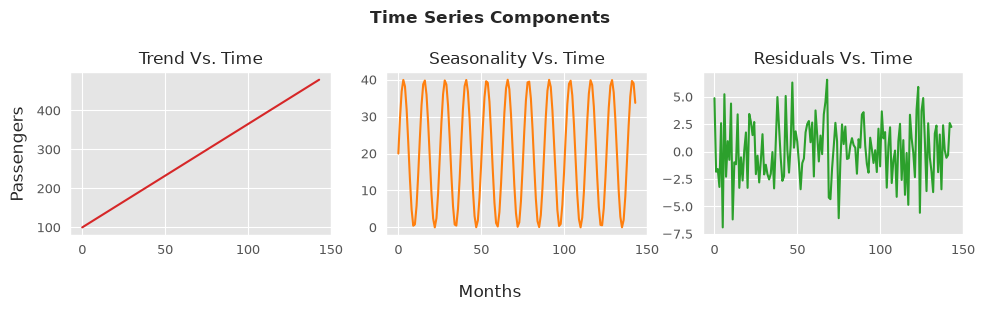

In [5]:
time = np.arange(144)
trend = time * 2.65 +100
seasonal = 20 + np.sin( time * 0.5) * 20
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].plot(time, trend, color='tab:red')
ax[1].plot(time, seasonal, color='tab:orange')
ax[2].plot(time, residuals, color='tab:green')
ax[0].set_title("Trend Vs. Time")
ax[1].set_title("Seasonality Vs. Time")
ax[2].set_title("Residuals Vs. Time")

for a in ax:
    a.grid(True)

fig.supxlabel('Months')
fig.supylabel('Passengers')
fig.suptitle('Time Series Components',fontweight='bold')
fig.tight_layout()

plt.show()

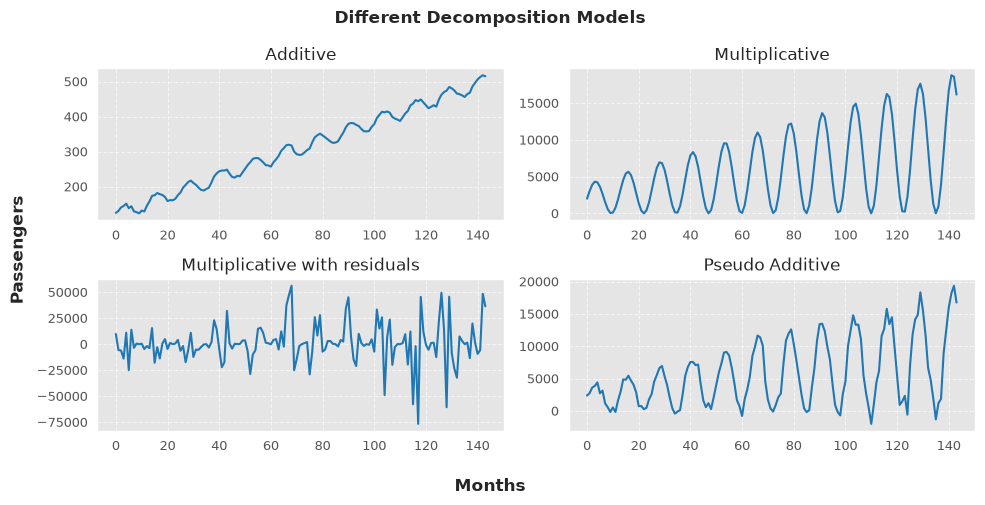

In [6]:
additive = trend + seasonal + residuals
multiplicative_wr = trend * seasonal * residuals
multiplicative = trend * seasonal ## series without residuals make the pattern clearer
pseudo_additive = trend * (seasonal + residuals-1)

fig, ax = plt.subplots(2,2,figsize=(10,5))
ax[0,0].plot(time,additive,'tab:blue')
ax[0,1].plot(time,multiplicative,'tab:blue')
ax[1,0].plot(time,multiplicative_wr,'tab:blue')
ax[1,1].plot(time,pseudo_additive,'tab:blue')

ax[0,0].set_title("Additive")
ax[0,1].set_title("Multiplicative")
ax[1,0].set_title("Multiplicative with residuals")
ax[1,1].set_title("Pseudo Additive")

for a in ax.flat:
    a.grid(True, linestyle='--', alpha=0.6)

fig.supxlabel("Months",fontweight='bold')
fig.supylabel("Passengers",fontweight='bold')
fig.suptitle("Different Decomposition Models",fontweight='bold')
fig.tight_layout()

plt.show()

#### **Different Decomposition Techniques**

**1. Classical Decomposition**

The classical decomposition method originated in the 1920s. It is a relatively simple procedure, and forms the starting point for most other methods of time series decomposition. There are two forms of classical decomposition: an additive decomposition and a multiplicative decomposition. These are described below for a time series with seasonal period $m$ (e.g., $m = 4$ for quarterly data, $m = 12$ for monthly data, $m = 7$ for daily data with a weekly pattern).

In classical decomposition, we assume that the seasonal component is constant from year to year. For multiplicative seasonality, the $m$ values that form the seasonal component are sometimes called the `“seasonal indices”`.

The **`Statsmodels`** library provides an implementation of the naive, or classical, decomposition method in a function called `seasonal_decompose()`. It requires that you specify whether the model is additive or multiplicative.

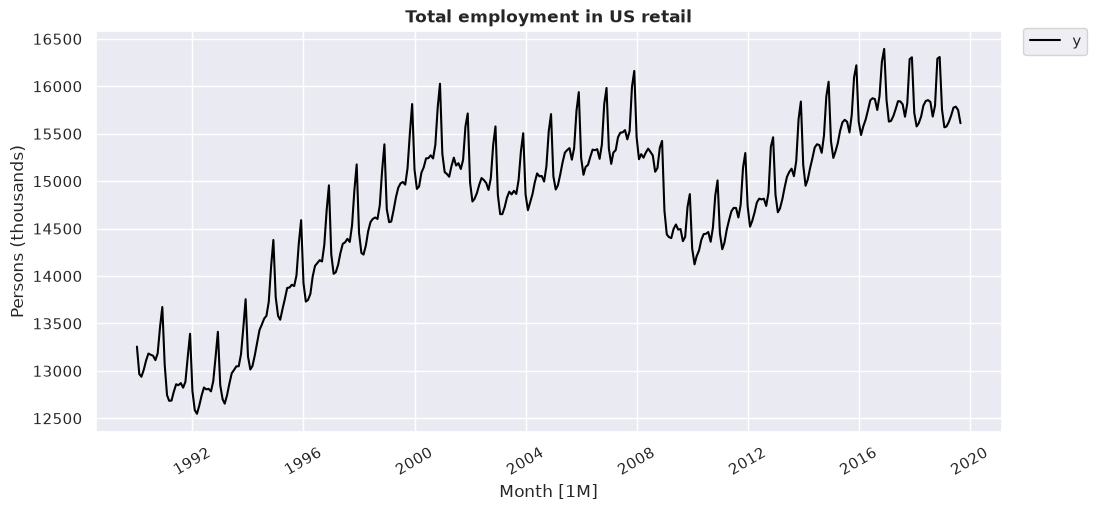

In [115]:
us_employment = pd.read_csv("data/us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")]

fig = plot_series_utils(us_retail_employment)
fig.set_size_inches(10, 5)

ax=fig.gca()

ax.set_xlabel("Month [1M]")
ax.set_ylabel("Persons (thousands)")
ax.set_title("Total employment in US retail",fontweight='bold')

fig

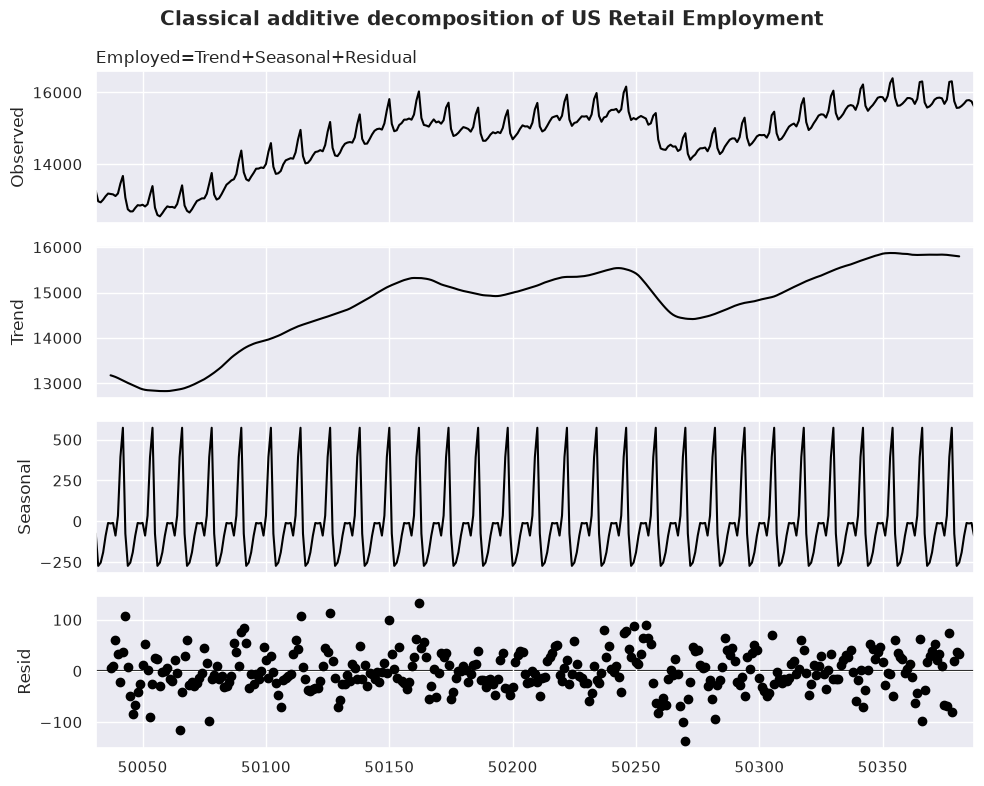

In [132]:
from statsmodels.tsa.seasonal import seasonal_decompose

additive_decomp = seasonal_decompose(us_retail_employment["y"].rename(""),model="additive",period=12)

# Plot decomposition 
fig = additive_decomp.plot()
fig.set_size_inches(10, 8)

# Adjust plot styling
for ax in fig.axes:
    ax.grid(True)
    ax.tick_params(axis="x", rotation=0)

fig.axes[0].set_title("Employed=Trend+Seasonal+Residual",loc='left')
fig.axes[0].set_ylabel("Observed")
plt.suptitle("Classical additive decomposition of US Retail Employment",fontweight='bold',ha='center')
plt.tight_layout()
plt.show()

In [ ]:
import requests
from io import StringIO

url = "https://www.census.gov/retail/marts/www/adv44X72.txt"
r = requests.get(url)

retail_sales = pd.read_fwf(StringIO(r.text[28:4405]))
seasonal_factors = pd.read_fwf(StringIO(r.text[4550:8965]))
retail_sales[retail_sales.columns[1:]] = retail_sales[retail_sales.columns[1:]]*seasonal_factors[seasonal_factors.columns[1:]]

retail_sales.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,142622.592,142314.966,154998.119,158481.711,164643.246,163623.075,164809.260,165173.004,160087.614,168387.882,166456.248,202738.419
1,1993,149668.500,145540.080,165837.498,171069.388,176419.200,176132.324,178107.686,178211.961,172369.408,177410.412,182454.370,219284.247
2,1994,157522.355,158016.163,187094.442,183626.655,189328.320,191743.800,187873.938,196494.130,188733.300,192362.688,197730.225,234901.495
3,1995,171615.408,167196.888,195374.179,190622.560,204794.040,205793.341,197716.230,208517.886,196706.249,198791.627,207208.810,240961.792
4,1996,180764.391,187015.000,205988.800,205526.708,220659.065,211568.740,211881.135,219912.378,204277.214,216819.156,217749.004,253004.370


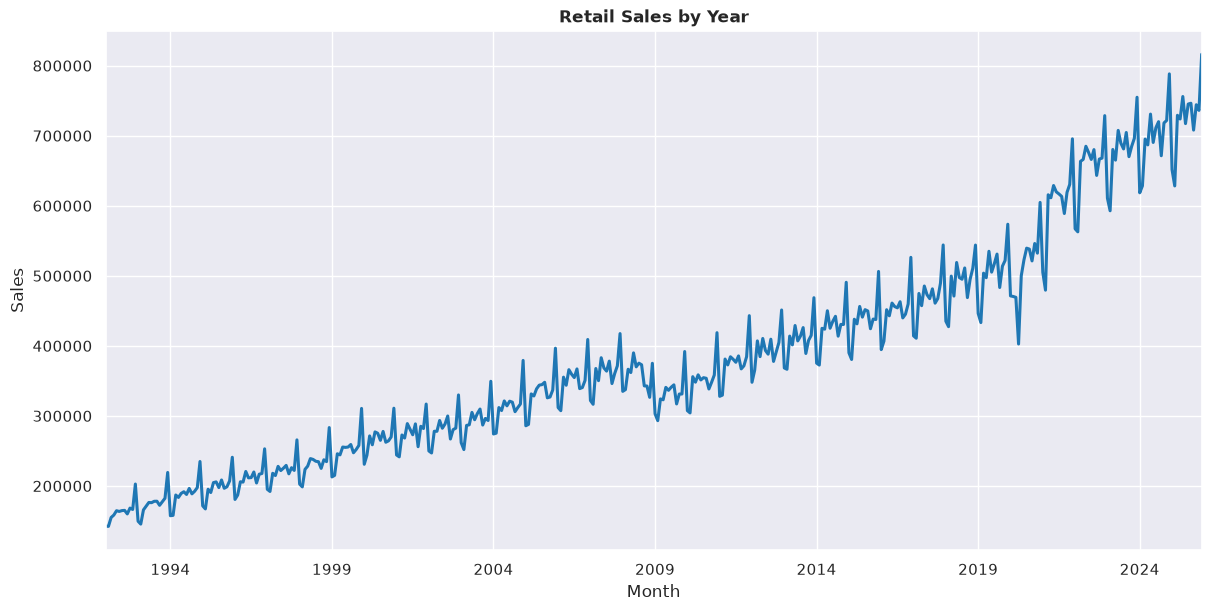

In [90]:
retail_sales_ts = retail_sales.melt(id_vars='YEAR',
            var_name='Month',
            value_name='Retail_Sales')

retail_sales_ts['Date'] = pd.to_datetime(retail_sales_ts['YEAR'].astype(str) + '-' 
                                         + retail_sales_ts['Month'], format='%Y-%b')

retail_sales_ts.sort_values(by="Date", inplace=True)

retail_sales_ts.set_index('Date')["Retail_Sales"].plot(figsize=(12,6),
                                                       color='tab:blue',
                                                       linewidth=2.2,
                                                        legend=False)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Retail Sales by Year",fontweight='bold')
plt.show()

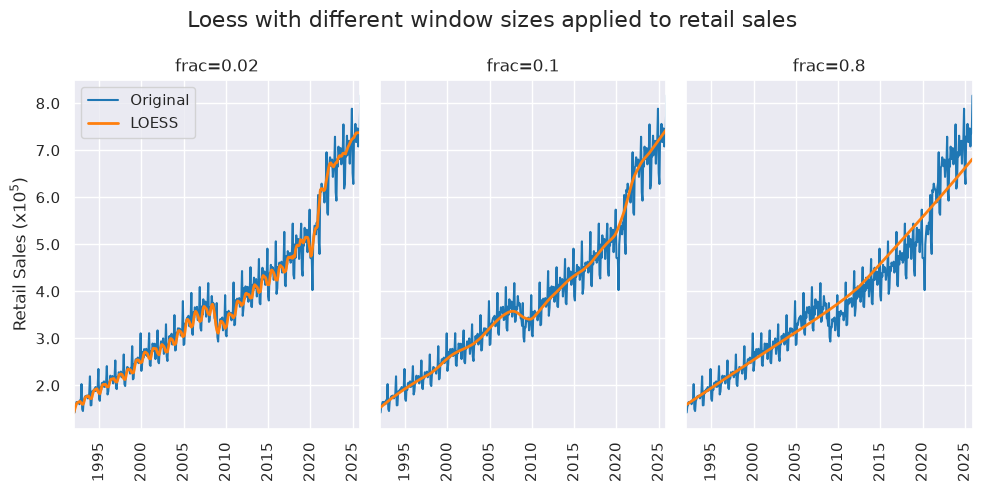

In [89]:
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

sns.set_style("darkgrid")
sns.set_context('notebook')

# Create LOWESS smoothings with different frac values
frac_values = [0.02, 0.1, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

for ax, frac in zip(axes, frac_values):
    # Compute LOWESS smoothing
    smoothed = sm.nonparametric.lowess(exog=retail_sales_ts['Date'],
                                       endog=retail_sales_ts['Retail_Sales'],frac=frac)

    retail_sales_ts[f'smoothed_{frac}'] = smoothed[:, 1]

    # Plot original
    ax.plot(retail_sales_ts['Date'], retail_sales_ts['Retail_Sales'], 
        color='tab:blue', 
        linewidth=1.5, 
        label="Original")
    
    #Plot smoothed
    ax.plot(retail_sales_ts['Date'], retail_sales_ts[f'smoothed_{frac}'], 
        color='tab:orange', 
        linewidth=2, 
        label="LOWESS")

    ax.set_title(f"frac={frac}")
    ax.grid(True)

axes[0].legend(["Original", "LOESS"])
axes[0].set_ylabel("Retail Sales (x$10^5$)")

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e5}'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(retail_sales_ts['Date'].min(), retail_sales_ts['Date'].max())
    ax.tick_params(axis='x',rotation=90)

# Chart Title
fig.suptitle(
    "Loess with different window sizes applied to retail sales",
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.show()
    